In [101]:
# NYC Taxi Trip Duration Prediction
import numpy as np
random_seed = 42
np.random.seed(random_seed)
from matplotlib import pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import skew, yeojohnson
import pandas as pd
from os.path import abspath
from sklearn.model_selection import train_test_split, GridSearchCV
import re

In [102]:
df = pd.read_csv('Homework1/train.csv', 
                 #parse_dates=['pickup_datetime', 'dropoff_datetime'],
                 dtype={'vendor_id': 'category',
                        'passenger_count': 'int8',
                        'store_and_fwd_flag': 'category'},
                 header=0)

df.head()

,id,vendor_id,pickup_datetime,dropoff_datetime,passenger_count,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,store_and_fwd_flag,trip_duration
0,id2875421,2,2016-03-14 17:24:55,2016-03-14 17:32:30,1,-73.982155,40.767937,-73.964630,40.765602,N,455
1,id2377394,1,2016-06-12 00:43:35,2016-06-12 00:54:38,1,-73.980415,40.738564,-73.999481,40.731152,N,663
2,id3858529,2,2016-01-19 11:35:24,2016-01-19 12:10:48,1,-73.979027,40.763939,-74.005333,40.710087,N,2124
3,id3504673,2,2016-04-06 19:32:31,2016-04-06 19:39:40,1,-74.010040,40.719971,-74.012268,40.706718,N,429
4,id2181028,2,2016-03-26 13:30:55,2016-03-26 13:38:10,1,-73.973053,40.793209,-73.972923,40.782520,N,435


In [103]:
df_test = pd.read_csv('Homework1/test.csv',
                      #parse_dates=['pickup_datetime'],
                      dtype={'vendor_id': 'category',
                             'passenger_count': 'int8',
                             'store_and_fwd_flag': 'category'},
                      header=0)
df_test.head()

,id,vendor_id,pickup_datetime,passenger_count,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,store_and_fwd_flag
0,id3004672,1,2016-06-30 23:59:58,1,-73.988129,40.732029,-73.990173,40.756680,N
1,id3505355,1,2016-06-30 23:59:53,1,-73.964203,40.679993,-73.959808,40.655403,N
2,id1217141,1,2016-06-30 23:59:47,1,-73.997437,40.737583,-73.986160,40.729523,N
3,id2150126,2,2016-06-30 23:59:41,1,-73.956070,40.771900,-73.986427,40.730469,N
4,id1598245,1,2016-06-30 23:59:33,1,-73.970215,40.761475,-73.961510,40.755890,N


Handling Uncommon Features

In [104]:
df = df.drop(columns=['dropoff_datetime'])

In [105]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1458644 entries, 0 to 1458643
Data columns (total 10 columns):
 #   Column              Non-Null Count    Dtype   
---  ------              --------------    -----   
 0   id                  1458644 non-null  object  
 1   vendor_id           1458644 non-null  category
 2   pickup_datetime     1458644 non-null  object  
 3   passenger_count     1458644 non-null  int8    
 4   pickup_longitude    1458644 non-null  float64 
 5   pickup_latitude     1458644 non-null  float64 
 6   dropoff_longitude   1458644 non-null  float64 
 7   dropoff_latitude    1458644 non-null  float64 
 8   store_and_fwd_flag  1458644 non-null  category
 9   trip_duration       1458644 non-null  int64   
dtypes: category(2), float64(4), int64(1), int8(1), object(2)
memory usage: 82.1+ MB


In [106]:
df_test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 625134 entries, 0 to 625133
Data columns (total 9 columns):
 #   Column              Non-Null Count   Dtype   
---  ------              --------------   -----   
 0   id                  625134 non-null  object  
 1   vendor_id           625134 non-null  category
 2   pickup_datetime     625134 non-null  object  
 3   passenger_count     625134 non-null  int8    
 4   pickup_longitude    625134 non-null  float64 
 5   pickup_latitude     625134 non-null  float64 
 6   dropoff_longitude   625134 non-null  float64 
 7   dropoff_latitude    625134 non-null  float64 
 8   store_and_fwd_flag  625134 non-null  category
dtypes: category(2), float64(4), int8(1), object(2)
memory usage: 30.4+ MB


Feature Engineering

In [107]:
tmp_pickupx = df.loc[0, ['pickup_latitude', 'pickup_longitude']]
tmp_dropoffx = df.loc[0, ['dropoff_latitude', 'dropoff_longitude']]
from sklearn.metrics.pairwise import haversine_distances as hd

In [108]:
list(tmp_pickupx.to_numpy())

[40.76793670654297, -73.98215484619139]

In [109]:
list(tmp_dropoffx.to_numpy())

[40.765602111816406, -73.96463012695312]

In [110]:
np.radians(list(tmp_pickupx.to_numpy()))

array([ 0.71153472, -1.29123219])

In [111]:
hd([np.radians(list(tmp_pickupx.to_numpy())),
   np.radians(list(tmp_dropoffx.to_numpy()))])[0, 1] * 3958.8

0.9311480242445478

In [112]:
earth_radius_miles = 3958.8
df['pickup_latitude'] = np.radians(df['pickup_latitude'])
df['pickup_longitude'] = np.radians(df['pickup_longitude'])
df['dropoff_latitude'] = np.radians(df['dropoff_latitude'])
df['dropoff_longitude'] = np.radians(df['dropoff_longitude'])
distance = df.apply(lambda x: hd([[x.pickup_latitude, x.pickup_longitude],
                                  [x.dropoff_latitude, x.dropoff_longitude]]
                                )[0,1] * earth_radius_miles,
                    axis=1)

In [113]:
df['distance'] = distance

In [114]:
df_test['pickup_latitude'] = np.radians(df_test['pickup_latitude'])
df_test['pickup_longitude'] = np.radians(df_test['pickup_longitude'])
df_test['dropoff_latitude'] = np.radians(df_test['dropoff_latitude'])
df_test['dropoff_longitude'] = np.radians(df_test['dropoff_longitude'])
df_test['distance'] = df_test.apply(lambda x: hd([[x.pickup_latitude, x.pickup_longitude],
                                  [x.dropoff_latitude, x.dropoff_longitude]]
                                )[0,1] * earth_radius_miles,
                                axis=1)

In [115]:
df.pickup_datetime.min()

'2016-01-01 00:00:17'

In [116]:
df.pickup_datetime.max()

'2016-06-30 23:59:39'

In [117]:
df = df.drop(columns=['pickup_latitude', 'pickup_longitude',
                      'dropoff_latitude', 'dropoff_longitude'])
df_test = df_test.drop(columns=['pickup_latitude', 'pickup_longitude',
                      'dropoff_latitude', 'dropoff_longitude'])

In [118]:
def map_month_name(x):
    month_name = {'01': 'Jan',
                  '02': 'Feb',
                  '03': 'Mar',
                  '04': 'Apr',
                  '05': 'May',
                  '06': 'Jun',
                  '07': 'Jul',
                  '08': 'Aug',
                  '09': 'Sep',
                  '10': 'Oct',
                  '11': 'Nov',
                  '12': 'Dec'}
    return month_name[x]

In [119]:
def datetime_transformer(df):
    pickup_complete_date = df.pickup_datetime.apply(lambda x: re.findall(r"\d{4}-\d{2}-\d{2}", 
                                                    x)[0])
    pickup_year = pickup_complete_date.apply(lambda x: x.split("-")[0])
    pickup_month = pickup_complete_date.apply(lambda x: x.split("-")[1])
    # pickup_date = pickup_complete_date.apply(lambda x: x.split("-")[2])
    pickup_dayofweek = pd.DatetimeIndex(pickup_complete_date).day_name()
    # pickup_dayofweek_idx = pd.DatetimeIndex(pickup_complete_date).dayofweek
    pickup_month = pickup_month.apply(lambda x: map_month_name(x))
    pickup_complete_time = df.pickup_datetime.apply(lambda x: re.findall(r"\d{2}:\d{2}:\d{2}", 
                                                    x)[0])
    pickup_hour = pickup_complete_time.apply(lambda x: x.split(":")[0])
    df['pickup_year'] = pickup_year
    df['pickup_month'] = pickup_month
    df['pickup_dayofweek'] = pickup_dayofweek
    df['pickup_hour'] = pickup_hour

    return df


In [120]:
df = datetime_transformer(df)
df_test = datetime_transformer(df_test)

#Handling Identifiers

In [121]:
df = df.drop(columns=['id'])
df_test = df_test.drop(columns=['id'])

In [122]:
df.columns

Index(['vendor_id', 'pickup_datetime', 'passenger_count', 'store_and_fwd_flag',
       'trip_duration', 'distance', 'pickup_year', 'pickup_month',
       'pickup_dayofweek', 'pickup_hour'],
      dtype='object')

In [ ]:
# I am writing this for a different project. Do not execute this
# df.to_csv("nyc_taxi_trip.csv", header=True, index=False)

Encode categorical variables

In [73]:
df = pd.get_dummies(df, columns=['pickup_year', 'pickup_month', 'pickup_hour', 'pickup_dayofweek', 'vendor_id', 'store_and_fwd_flag'])
df_test = pd.get_dummies(df_test, columns=['pickup_year', 'pickup_month', 'pickup_hour', 'pickup_dayofweek', 'vendor_id', 'store_and_fwd_flag'])

In [74]:
df.columns

Index(['pickup_datetime', 'passenger_count', 'trip_duration', 'distance',
       'pickup_year_2016', 'pickup_month_Apr', 'pickup_month_Feb',
       'pickup_month_Jan', 'pickup_month_Jun', 'pickup_month_Mar',
       'pickup_month_May', 'pickup_hour_00', 'pickup_hour_01',
       'pickup_hour_02', 'pickup_hour_03', 'pickup_hour_04', 'pickup_hour_05',
       'pickup_hour_06', 'pickup_hour_07', 'pickup_hour_08', 'pickup_hour_09',
       'pickup_hour_10', 'pickup_hour_11', 'pickup_hour_12', 'pickup_hour_13',
       'pickup_hour_14', 'pickup_hour_15', 'pickup_hour_16', 'pickup_hour_17',
       'pickup_hour_18', 'pickup_hour_19', 'pickup_hour_20', 'pickup_hour_21',
       'pickup_hour_22', 'pickup_hour_23', 'pickup_dayofweek_Friday',
       'pickup_dayofweek_Monday', 'pickup_dayofweek_Saturday',
       'pickup_dayofweek_Sunday', 'pickup_dayofweek_Thursday',
       'pickup_dayofweek_Tuesday', 'pickup_dayofweek_Wednesday', 'vendor_id_1',
       'vendor_id_2', 'store_and_fwd_flag_N', 'store_and_f

In [75]:
df_test.columns

Index(['pickup_datetime', 'passenger_count', 'distance', 'pickup_year_2016',
       'pickup_month_Apr', 'pickup_month_Feb', 'pickup_month_Jan',
       'pickup_month_Jun', 'pickup_month_Mar', 'pickup_month_May',
       'pickup_hour_00', 'pickup_hour_01', 'pickup_hour_02', 'pickup_hour_03',
       'pickup_hour_04', 'pickup_hour_05', 'pickup_hour_06', 'pickup_hour_07',
       'pickup_hour_08', 'pickup_hour_09', 'pickup_hour_10', 'pickup_hour_11',
       'pickup_hour_12', 'pickup_hour_13', 'pickup_hour_14', 'pickup_hour_15',
       'pickup_hour_16', 'pickup_hour_17', 'pickup_hour_18', 'pickup_hour_19',
       'pickup_hour_20', 'pickup_hour_21', 'pickup_hour_22', 'pickup_hour_23',
       'pickup_dayofweek_Friday', 'pickup_dayofweek_Monday',
       'pickup_dayofweek_Saturday', 'pickup_dayofweek_Sunday',
       'pickup_dayofweek_Thursday', 'pickup_dayofweek_Tuesday',
       'pickup_dayofweek_Wednesday', 'vendor_id_1', 'vendor_id_2',
       'store_and_fwd_flag_N', 'store_and_fwd_flag_Y'],
    

In [76]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1458644 entries, 0 to 1458643
Data columns (total 46 columns):
 #   Column                      Non-Null Count    Dtype  
---  ------                      --------------    -----  
 0   pickup_datetime             1458644 non-null  object 
 1   passenger_count             1458644 non-null  int8   
 2   trip_duration               1458644 non-null  int64  
 3   distance                    1458644 non-null  float64
 4   pickup_year_2016            1458644 non-null  bool   
 5   pickup_month_Apr            1458644 non-null  bool   
 6   pickup_month_Feb            1458644 non-null  bool   
 7   pickup_month_Jan            1458644 non-null  bool   
 8   pickup_month_Jun            1458644 non-null  bool   
 9   pickup_month_Mar            1458644 non-null  bool   
 10  pickup_month_May            1458644 non-null  bool   
 11  pickup_hour_00              1458644 non-null  bool   
 12  pickup_hour_01              1458644 non-null  bool   
 1

EDA

Text(0, 0.5, 'Count')

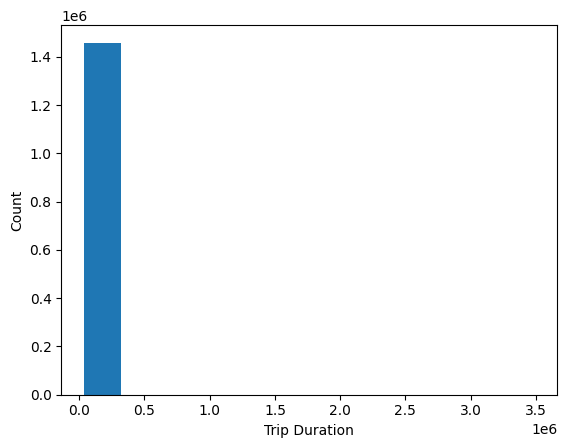

In [77]:
plt.hist(df['trip_duration'], rwidth=0.8)
plt.xlabel('Trip Duration')
plt.ylabel('Count')

In [78]:
df.trip_duration.describe()

count    1.458644e+06
mean     9.594923e+02
std      5.237432e+03
min      1.000000e+00
25%      3.970000e+02
50%      6.620000e+02
75%      1.075000e+03
max      3.526282e+06
Name: trip_duration, dtype: float64

Remove outliers

In [79]:
df = df.loc[(df['trip_duration'] >= 60) &
            (df['trip_duration'] <= 7200), :]

<AxesSubplot: >

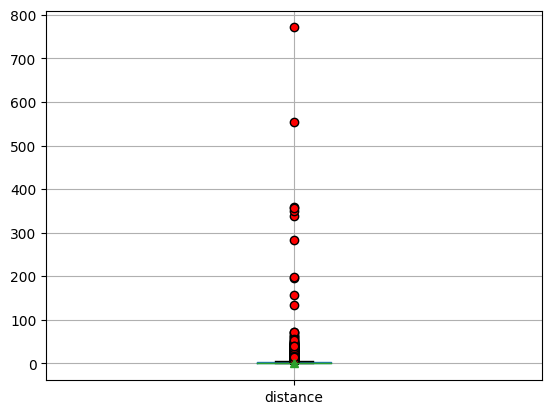

In [80]:
df.boxplot(column='distance',
           showfliers=True, flierprops={'markerfacecolor':'red',
                                        'markeredgecolor':'black'},
           showmeans=True, grid=True)

In [81]:
df = df.loc[(df['distance'] > 0.05) & 
            (df['trip_duration'] >= 60), :]

In [82]:
df.shape

(1440763, 46)

Fix the skewness by applying log transformation to the y variable

In [83]:
df['trip_duration'] = np.log1p(df.trip_duration)

<AxesSubplot: >

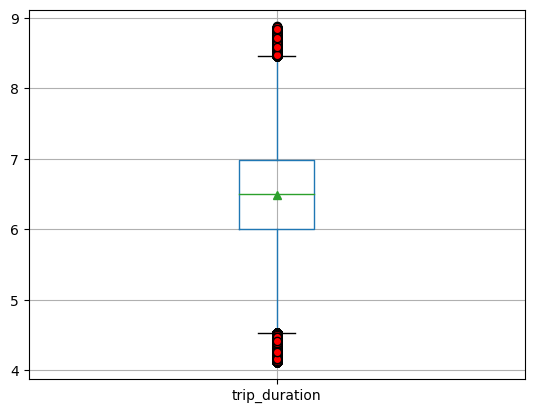

In [84]:
df.boxplot(column='trip_duration',
           showfliers=True, flierprops={'markerfacecolor':'red',
                                        'markeredgecolor':'black'},
           showmeans=True, grid=True)

In [85]:
df_train, df_val = train_test_split(df, test_size=0.2,
                                    random_state=random_seed)

In [86]:
print(f"df_train.shape={df_train.shape}")
print(f"df_val.shape={df_val.shape}")
print(f"df_test.shape={df_test.shape}")

df_train.shape=(1152610, 46)
df_val.shape=(288153, 46)
df_test.shape=(625134, 45)


The test shows 19 features while the training and the validation shows 20 because we haven't yet removed the target column from train and val sets

In [87]:
y_train = df_train.trip_duration
y_val = df_val.trip_duration
df_train = df_train.drop(columns=['trip_duration'])
df_val = df_val.drop(columns=['trip_duration'])

In [88]:
print(f"df_train.shape={df_train.shape}")
print(f"df_val.shape={df_val.shape}")
print(f"df_test.shape={df_test.shape}")

df_train.shape=(1152610, 45)
df_val.shape=(288153, 45)
df_test.shape=(625134, 45)


In [89]:
numerical_vars = [var for var in df_train.columns 
                    if df_train[var].dtype == "int8" 
                    or df_train[var].dtype == "float64"
                    or df_train[var].dtype == "int32"]

In [90]:
numerical_vars

['passenger_count', 'distance']

In [91]:
df_train = df_train.drop(columns=['pickup_datetime'])
df_val = df_val.drop(columns=['pickup_datetime'])
df_test = df_test.drop(columns=['pickup_datetime'])

In [92]:
cat_vars = list(set(df_train.columns) - set(numerical_vars))
print(pd.Series(cat_vars))

0                 pickup_hour_01
1                    vendor_id_2
2                 pickup_hour_14
3                 pickup_hour_05
4      pickup_dayofweek_Saturday
5               pickup_month_Feb
6               pickup_month_Jun
7               pickup_month_Apr
8                 pickup_hour_12
9        pickup_dayofweek_Monday
10              pickup_month_May
11                pickup_hour_10
12              pickup_month_Mar
13                pickup_hour_22
14                pickup_hour_07
15                pickup_hour_21
16                pickup_hour_04
17                pickup_hour_06
18     pickup_dayofweek_Thursday
19                pickup_hour_23
20                pickup_hour_00
21              pickup_year_2016
22                pickup_hour_16
23       pickup_dayofweek_Sunday
24      pickup_dayofweek_Tuesday
25          store_and_fwd_flag_N
26                pickup_hour_20
27                pickup_hour_18
28                pickup_hour_11
29          store_and_fwd_flag_Y
30        

In [93]:
df_train.head()

,passenger_count,distance,pickup_year_2016,pickup_month_Apr,pickup_month_Feb,pickup_month_Jan,pickup_month_Jun,pickup_month_Mar,pickup_month_May,pickup_hour_00,...,pickup_dayofweek_Monday,pickup_dayofweek_Saturday,pickup_dayofweek_Sunday,pickup_dayofweek_Thursday,pickup_dayofweek_Tuesday,pickup_dayofweek_Wednesday,vendor_id_1,vendor_id_2,store_and_fwd_flag_N,store_and_fwd_flag_Y
778250,1,1.419982,True,False,False,False,False,True,False,False,...,False,False,False,False,False,False,False,True,True,False
395490,1,3.200825,True,False,False,True,False,False,False,False,...,False,False,False,True,False,False,True,False,True,False
1031995,5,2.453089,True,False,False,False,True,False,False,False,...,False,True,False,False,False,False,False,True,True,False
1454609,1,1.410444,True,False,False,True,False,False,False,False,...,False,False,False,False,False,True,False,True,True,False
247294,1,1.573019,True,True,False,False,False,False,False,False,...,False,True,False,False,False,False,False,True,True,False


In [94]:
df_val.head()

,passenger_count,distance,pickup_year_2016,pickup_month_Apr,pickup_month_Feb,pickup_month_Jan,pickup_month_Jun,pickup_month_Mar,pickup_month_May,pickup_hour_00,...,pickup_dayofweek_Monday,pickup_dayofweek_Saturday,pickup_dayofweek_Sunday,pickup_dayofweek_Thursday,pickup_dayofweek_Tuesday,pickup_dayofweek_Wednesday,vendor_id_1,vendor_id_2,store_and_fwd_flag_N,store_and_fwd_flag_Y
699592,5,2.318769,True,False,False,True,False,False,False,False,...,False,True,False,False,False,False,False,True,True,False
1398667,3,1.190161,True,False,True,False,False,False,False,False,...,False,False,True,False,False,False,True,False,True,False
1244781,1,0.569230,True,False,True,False,False,False,False,False,...,False,False,False,False,False,False,True,False,True,False
468619,2,0.306490,True,True,False,False,False,False,False,False,...,False,False,False,False,False,False,True,False,True,False
339376,1,0.708890,True,True,False,False,False,False,False,False,...,False,True,False,False,False,False,True,False,True,False


In [95]:
df_test.head()

,passenger_count,distance,pickup_year_2016,pickup_month_Apr,pickup_month_Feb,pickup_month_Jan,pickup_month_Jun,pickup_month_Mar,pickup_month_May,pickup_hour_00,...,pickup_dayofweek_Monday,pickup_dayofweek_Saturday,pickup_dayofweek_Sunday,pickup_dayofweek_Thursday,pickup_dayofweek_Tuesday,pickup_dayofweek_Wednesday,vendor_id_1,vendor_id_2,store_and_fwd_flag_N,store_and_fwd_flag_Y
0,1,1.706569,True,False,False,False,True,False,False,False,...,False,False,False,True,False,False,True,False,True,False
1,1,1.714531,True,False,False,False,True,False,False,False,...,False,False,False,True,False,False,True,False,True,False
2,1,0.811616,True,False,False,False,True,False,False,False,...,False,False,False,True,False,False,True,False,True,False
3,1,3.274096,True,False,False,False,True,False,False,False,...,False,False,False,True,False,False,False,True,True,False
4,1,0.597046,True,False,False,False,True,False,False,False,...,False,False,False,True,False,False,True,False,True,False


In [96]:
from sklearn.preprocessing import StandardScaler

ss = StandardScaler()

In [97]:
numerical_vars

['passenger_count', 'distance']

In [98]:
df_train.loc[:, numerical_vars] = ss.fit_transform(df_train[numerical_vars])
df_val.loc[:, numerical_vars] = ss.transform(df_val[numerical_vars])
df_test.loc[:, numerical_vars] = ss.transform(df_test[numerical_vars])

C:\Users\Rajkumar\AppData\Local\Temp\ipykernel_42196\948823218.py:1: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[-0.50615172 -0.50615172  2.53898034 ... -0.50615172 -0.50615172
  1.01641431]' has dtype incompatible with int8, please explicitly cast to a compatible dtype first.
  df_train.loc[:, numerical_vars] = ss.fit_transform(df_train[numerical_vars])
C:\Users\Rajkumar\AppData\Local\Temp\ipykernel_42196\948823218.py:2: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[ 2.53898034  1.01641431 -0.50615172 ... -0.50615172 -0.50615172
 -0.50615172]' has dtype incompatible with int8, please explicitly cast to a compatible dtype first.
  df_val.loc[:, numerical_vars] = ss.transform(df_val[numerical_vars])
C:\Users\Rajkumar\AppData\Local\Temp\ipykernel_42196\948823218.py:3: FutureWarning: Setting an item of incompatible dtype is deprecated and will

In [99]:
df_train.columns

Index(['passenger_count', 'distance', 'pickup_year_2016', 'pickup_month_Apr',
       'pickup_month_Feb', 'pickup_month_Jan', 'pickup_month_Jun',
       'pickup_month_Mar', 'pickup_month_May', 'pickup_hour_00',
       'pickup_hour_01', 'pickup_hour_02', 'pickup_hour_03', 'pickup_hour_04',
       'pickup_hour_05', 'pickup_hour_06', 'pickup_hour_07', 'pickup_hour_08',
       'pickup_hour_09', 'pickup_hour_10', 'pickup_hour_11', 'pickup_hour_12',
       'pickup_hour_13', 'pickup_hour_14', 'pickup_hour_15', 'pickup_hour_16',
       'pickup_hour_17', 'pickup_hour_18', 'pickup_hour_19', 'pickup_hour_20',
       'pickup_hour_21', 'pickup_hour_22', 'pickup_hour_23',
       'pickup_dayofweek_Friday', 'pickup_dayofweek_Monday',
       'pickup_dayofweek_Saturday', 'pickup_dayofweek_Sunday',
       'pickup_dayofweek_Thursday', 'pickup_dayofweek_Tuesday',
       'pickup_dayofweek_Wednesday', 'vendor_id_1', 'vendor_id_2',
       'store_and_fwd_flag_N', 'store_and_fwd_flag_Y'],
      dtype='object')

In [ ]:
# df_train.to_csv("processed_X_train.csv", header=True, index=False)
# df_val.to_csv("processed_X_val.csv", header=True, index=False)
# y_train.to_csv("y_train.csv", index=False)
# y_val.to_csv("y_val.csv", index=False)

In [48]:
X_train = df_train.values
X_val = df_val.values
X_test = df_test.values

y_train = y_train.values
y_val = y_val.values

Hyperparameter Grid

In [65]:
from sklearn.linear_model import SGDRegressor, Ridge
from sklearn.ensemble import RandomForestRegressor

models = {'sgd': SGDRegressor(random_state=random_seed, early_stopping=True,
                              max_iter=5000),
          'lr': Ridge(random_state=random_seed),
          'rf': RandomForestRegressor()}

In [66]:
from sklearn.pipeline import Pipeline

pipes = {}
for acronym, model in models.items():
    pipes[acronym] = Pipeline([('model', model)])

In [67]:
params_grid = {}
# The parameter grid of eta
eta_grid = [1e-4, 1e-3, 1e-2, 1e-1]

# The parameter grid of alpha
alpha_grid = [0.01, 0.05, 0.1, 0.15, 0.2, 2.5]

# Update param_grids
params_grid['sgd'] = [{'model__eta0': eta_grid,
                       'model__alpha': alpha_grid}]
params_grid['lr'] =  [{'model__alpha': alpha_grid}]
params_grid['rf'] =  [{'model__n_estimators': [20, 40, 80, 100],
                       'model__max_depth': [6, 10, 20, 40]}]

In [53]:
from sklearn.model_selection import PredefinedSplit

# Combine the feature matrix in the training and validation data
X_train_val = np.vstack((X_train, X_val))

# Combine the target vector in the training and validation data
y_train_val = np.vstack((y_train.reshape(-1, 1), y_val.reshape(-1, 1))).reshape(-1)

# Get the indices of training and validation data
train_val_idxs = np.append(np.full(X_train.shape[0], -1), np.full(X_val.shape[0], 0))

# The PredefinedSplit
ps = PredefinedSplit(train_val_idxs)

In [54]:
cat_vars

['pickup_month_May',
 'pickup_hour_20',
 'pickup_dayofweek_Saturday',
 'store_and_fwd_flag_N',
 'pickup_year_2016',
 'pickup_hour_11',
 'pickup_hour_15',
 'pickup_dayofweek_Thursday',
 'pickup_hour_18',
 'pickup_hour_02',
 'pickup_dayofweek_Wednesday',
 'vendor_id_2',
 'pickup_month_Jan',
 'pickup_hour_16',
 'store_and_fwd_flag_Y',
 'pickup_month_Apr',
 'pickup_hour_19',
 'pickup_dayofweek_Monday',
 'pickup_dayofweek_Friday',
 'pickup_month_Jun',
 'pickup_dayofweek_Sunday',
 'pickup_hour_03',
 'pickup_hour_01',
 'pickup_hour_09',
 'pickup_hour_21',
 'pickup_hour_12',
 'pickup_hour_14',
 'pickup_hour_17',
 'pickup_hour_10',
 'pickup_hour_22',
 'pickup_hour_04',
 'pickup_month_Feb',
 'pickup_hour_23',
 'pickup_hour_13',
 'pickup_hour_07',
 'pickup_month_Mar',
 'pickup_hour_00',
 'pickup_hour_08',
 'pickup_dayofweek_Tuesday',
 'vendor_id_1',
 'pickup_hour_05',
 'pickup_hour_06']

In [55]:
df_train

,passenger_count,distance,pickup_year_2016,pickup_month_Apr,pickup_month_Feb,pickup_month_Jan,pickup_month_Jun,pickup_month_Mar,pickup_month_May,pickup_hour_00,...,pickup_dayofweek_Monday,pickup_dayofweek_Saturday,pickup_dayofweek_Sunday,pickup_dayofweek_Thursday,pickup_dayofweek_Tuesday,pickup_dayofweek_Wednesday,vendor_id_1,vendor_id_2,store_and_fwd_flag_N,store_and_fwd_flag_Y
778250,-0.506152,-0.281156,True,False,False,False,False,True,False,False,...,False,False,False,False,False,False,False,True,True,False
395490,-0.506152,0.397326,True,False,False,True,False,False,False,False,...,False,False,False,True,False,False,True,False,True,False
1031995,2.538980,0.112447,True,False,False,False,True,False,False,False,...,False,True,False,False,False,False,False,True,True,False
1454609,-0.506152,-0.284790,True,False,False,True,False,False,False,False,...,False,False,False,False,False,True,False,True,True,False
247294,-0.506152,-0.222851,True,True,False,False,False,False,False,False,...,False,True,False,False,False,False,False,True,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
262382,-0.506152,0.863173,True,False,False,True,False,False,False,False,...,False,False,False,False,False,True,True,False,True,False
1431982,-0.506152,-0.582463,True,False,False,True,False,False,False,False,...,False,False,False,False,False,False,True,False,True,False
133558,-0.506152,-0.578060,True,True,False,False,False,False,False,False,...,False,False,False,False,False,False,True,False,True,False
679524,-0.506152,0.001845,True,False,True,False,False,False,False,False,...,False,False,False,False,False,False,False,True,True,False


In [68]:
from sklearn.model_selection import GridSearchCV

# The list of [best_score_, best_params_, best_estimator_] obtained by GridSearchCV
best_score_params_estimator_gs = {}
overall_cv_results = {}

# For each model
gs = None # can access the model after refit
for acronym in pipes.keys():
    # GridSearchCV
    gs = GridSearchCV(estimator=pipes[acronym],
                      param_grid=params_grid[acronym],
                      scoring='neg_mean_squared_error',
                      n_jobs=16,
                      cv=ps,
                      verbose=0,
                      return_train_score=True)
        
    # Fit the pipeline
    gs = gs.fit(X_train_val, y_train_val)
    
    # Update best_score_params_estimator_gs
    best_score_params_estimator_gs[acronym] = [np.round(gs.best_score_, 3), gs.best_params_, gs.best_estimator_]
    
    # Sort cv_results in ascending order of 'rank_test_score' and 'std_test_score'
    cv_results = pd.DataFrame.from_dict(gs.cv_results_).sort_values(by=['rank_test_score', 'std_test_score'])
    
    # For reference...
    overall_cv_results[acronym] = cv_results
    
    # Get the important columns in cv_results
    important_columns = ['rank_test_score',
                         'mean_test_score', 
                         'std_test_score', 
                         'mean_train_score', 
                         'std_train_score',
                         'mean_fit_time', 
                         'std_fit_time',                        
                         'mean_score_time', 
                         'std_score_time']
    
    # Move the important columns ahead
    # cv_results = cv_results[important_columns + sorted(list(set(cv_results.columns) - set(important_columns)))]

    # Write cv_results file
    # cv_results.to_csv(path_or_buf=abspath_curr + 'result/cv_results/GridSearchCV/' + acronym + '.csv', index=False)

# Sort best_score_params_estimator_gs in descending order of the best_score_
# best_score_params_estimator_gs = sorted(best_score_params_estimator_gs, key=lambda x : x[0], reverse=True)

In [69]:
cv_results[important_columns]

,rank_test_score,mean_test_score,std_test_score,mean_train_score,std_train_score,mean_fit_time,std_fit_time,mean_score_time,std_score_time
11,1,-0.157591,0.0,-0.134831,0.0,754.994155,0.0,2.963151,0.0
10,2,-0.157721,0.0,-0.134898,0.0,638.460267,0.0,2.450192,0.0
9,3,-0.157860,0.0,-0.134992,0.0,380.460671,0.0,1.734104,0.0
8,4,-0.158320,0.0,-0.135616,0.0,210.847848,0.0,1.346152,0.0
15,5,-0.170744,0.0,-0.039831,0.0,952.301630,0.0,9.807933,0.0
14,6,-0.171140,0.0,-0.039974,0.0,796.758805,0.0,8.042761,0.0
7,7,-0.172410,0.0,-0.170527,0.0,531.044134,0.0,1.436237,0.0
6,8,-0.172468,0.0,-0.170567,0.0,450.483352,0.0,1.241583,0.0
13,9,-0.172556,0.0,-0.040979,0.0,470.225209,0.0,5.213499,0.0
5,10,-0.172560,0.0,-0.170617,0.0,256.347015,0.0,0.947742,0.0


In [71]:
best_scores = {}
best_alpha = {}
best_eta0 = {}

for acronym in pipes.keys():
    best_scores[acronym] = best_score_params_estimator_gs[acronym][0]
    if acronym != 'rf':
        best_alpha[acronym] = best_score_params_estimator_gs[acronym][1]['model__alpha']
    if acronym == 'sgd':
        best_eta0[acronym] = best_score_params_estimator_gs[acronym][1]['model__eta0']

pd.DataFrame([best_scores, best_alpha, best_eta0]).T.rename(columns={0:'best_score', 
                                                                    1:'best_alpha',
                                                                    2:'best_eta0'})


,best_score,best_alpha,best_eta0
sgd,-0.347,0.15,0.001
lr,-0.343,2.50,NaN
rf,-0.158,NaN,NaN


In [72]:
from sklearn.metrics import r2_score

tr_pred = gs.best_estimator_.predict(X_train)
val_pred = gs.best_estimator_.predict(X_val)
val_r2 = r2_score(y_val, val_pred)
tr_r2 = r2_score(y_train, tr_pred)
p = X_train.shape[1]
adj_r2_score = 1 - (((1 - val_r2) * (len(y_val) - 1))/(len(y_val) - p - 1))
print(f"tr_r2 score: {tr_r2:.3f}")
print(f"R2 score: {val_r2:.3f}, Adjusted R2 score: {adj_r2_score:.3f}")

tr_r2 score: 0.741
R2 score: 0.740, Adjusted R2 score: 0.740
